# Fourier Neural Operator for Accelerating 2-D Lid-Driven Cavity Flow Simulation

This project trains neural operator surrogates for transient two-dimensional lid-driven cavity flow. The model receives several previous flow fields and predicts the next field on the same spatial grid.

For an incompressible flow field

$$
\mathbf{u}(x,y,t) = (u(x,y,t), v(x,y,t)),
$$

the physical constraint is

$$
\nabla \cdot \mathbf{u} = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0.
$$

The experiments compare three models:

1. A data-only FNO baseline.
2. A physics-informed FNO using physical-space data loss, divergence loss, and a boundary penalty.
3. A Fourier-space data-loss ablation using the same physical penalties.

The main evaluation criteria are velocity RMSE, divergence error, boundary RMSE, Reynolds-number generalization, inference time, and training stability under different random seeds and temporal-window offsets.



In [1]:
from __future__ import annotations

import copy
import csv
import json
import math
import os
import random
import re
import time
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Iterable, Sequence

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    pd = None

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())

torch: 2.10.0+cu130
cuda available: True


## 1. Configuration

The configuration cell defines the flow variables, Reynolds-number split, temporal window length, FNO hyperparameters, optimizer settings, and loss weights.

Each frame contains pressure and two velocity components,

$$
q_t(x,y) = [p_t(x,y), u_t(x,y), v_t(x,y)].
$$

The input tensor consists of `input_steps` previous frames and the target is the next `pred_steps` frame. The default split trains on several Reynolds numbers and evaluates generalization on held-out Reynolds numbers.



In [2]:
@dataclass
class ProjectConfig:
    data_dir: Path = Path('Transient_k-e')
    output_dir: Path = Path('outputs')
    model_dir: Path = Path('outputs/models')
    figure_dir: Path = Path('outputs/figures')

    # Source code uses channels p, U:0, U:1. U:2 is zero for this 2-D case and is not used.
    channels: tuple[str, ...] = ('p', 'U:0', 'U:1')
    pressure_index: int = 0
    u_index: int = 1
    v_index: int = 2

    # Train on several Reynolds numbers and hold out separate Reynolds numbers for generalization.
    train_re: tuple[str, ...] = ('01k', '02k', '04k', '06k', '14k', '16k', '18k', '20k')
    val_re: tuple[str, ...] = ('10k',)
    extra_test_re: tuple[str, ...] = ('08k', '12k')

    input_steps: int = 3
    pred_steps: int = 1
    output_steps: int = 1
    resolution: int | None = None
    domain_length: float = 0.1
    require_consecutive_frames: bool = True
    normalize: bool = False

    batch_size: int = 4
    num_workers: int = 0
    seed: int = 228

    # FNO defaults are stronger than the tiny source demo config but still practical on a single GPU.
    modes: int = 12
    width: int = 32
    layers: int = 4

    max_epochs: int = 200
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    scheduler_factor: float = 0.5
    scheduler_patience: int = 10
    early_stop_patience: int = 40
    grad_clip_norm: float | None = 1.0

    # Main experiment: balanced physical divergence and boundary penalties.
    data_loss_space: str = 'physical'  # 'physical' or 'fourier'
    lambda_div: float = 0.02
    lambda_bc: float = 0.01

cfg = ProjectConfig()
for directory in (cfg.output_dir, cfg.model_dir, cfg.figure_dir):
    directory.mkdir(parents=True, exist_ok=True)

asdict(cfg)

{'data_dir': WindowsPath('Transient_k-e'),
 'output_dir': WindowsPath('outputs'),
 'model_dir': WindowsPath('outputs/models'),
 'figure_dir': WindowsPath('outputs/figures'),
 'channels': ('p', 'U:0', 'U:1'),
 'pressure_index': 0,
 'u_index': 1,
 'v_index': 2,
 'train_re': ('01k', '02k', '04k', '06k', '14k', '16k', '18k', '20k'),
 'val_re': ('10k',),
 'extra_test_re': ('08k', '12k'),
 'input_steps': 3,
 'pred_steps': 1,
 'output_steps': 1,
 'resolution': None,
 'domain_length': 0.1,
 'require_consecutive_frames': True,
 'normalize': False,
 'batch_size': 4,
 'num_workers': 0,
 'seed': 228,
 'modes': 12,
 'width': 32,
 'layers': 4,
 'max_epochs': 200,
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'scheduler_factor': 0.5,
 'scheduler_patience': 10,
 'early_stop_patience': 40,
 'grad_clip_norm': 1.0,
 'data_loss_space': 'physical',
 'lambda_div': 0.02,
 'lambda_bc': 0.01}

In [3]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(cfg.seed)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

## 2. Data Loading

Each CSV file stores one simulation frame with point coordinates and flow variables. The loader reconstructs the structured two-dimensional grid by selecting one thin `z` slice, sorting points by `(y, x)`, and reshaping the data into

$$
(H, W, C),
$$

where `H` and `W` are spatial grid dimensions and `C` is the number of selected variables.

Training samples are built as sliding temporal windows:

$$
X = [q_t, q_{t+1}, \ldots, q_{t+k-1}], \qquad
Y = [q_{t+k}, \ldots, q_{t+k+m-1}],
$$

where `k = input_steps` and `m = pred_steps`. Windows are formed only inside consecutive timestep runs, so non-adjacent CSV frames are not treated as consecutive dynamics.



In [4]:
def parse_timestep(path: Path) -> int:
    match = re.search(r'0\.(\d+)\.csv$', path.name)
    if not match:
        raise ValueError(f'Cannot parse timestep from {path}')
    return int(match.group(1))


def list_re_dirs(data_dir: Path) -> dict[str, Path]:
    return {path.name: path for path in sorted(data_dir.iterdir()) if path.is_dir()}


def sorted_csv_files(re_dir: Path) -> list[Path]:
    return sorted(re_dir.glob('*.csv'), key=parse_timestep)


def group_consecutive_files(paths: Sequence[Path], require_consecutive: bool = True) -> list[list[Path]]:
    if not paths:
        return []
    if not require_consecutive:
        return [list(paths)]

    groups: list[list[Path]] = [[paths[0]]]
    previous_step = parse_timestep(paths[0])
    for path in paths[1:]:
        step = parse_timestep(path)
        if step == previous_step + 1:
            groups[-1].append(path)
        else:
            groups.append([path])
        previous_step = step
    return groups


def csv_header(path: Path) -> list[str]:
    with path.open('r', newline='') as file:
        return [column.strip().strip('"') for column in next(csv.reader(file))]


def infer_grid_shape_from_csv(path: Path) -> tuple[int, int]:
    header = csv_header(path)
    if {'Points:0', 'Points:1'}.issubset(header):
        x_col = header.index('Points:0')
        y_col = header.index('Points:1')
        points = np.loadtxt(path, delimiter=',', skiprows=1, usecols=(x_col, y_col), dtype=np.float64)
        height = len(np.unique(points[:, 1]))
        width = len(np.unique(points[:, 0]))
        if height * width <= points.shape[0]:
            return height, width

    with path.open('r') as file:
        row_count = sum(1 for _ in file) - 1
    resolution = int(round(math.sqrt(row_count)))
    if resolution * resolution != row_count:
        raise ValueError(f'{path} has {row_count} data rows and no usable point coordinates')
    return resolution, resolution


def infer_resolution_from_csv(path: Path) -> int:
    height, width = infer_grid_shape_from_csv(path)
    if height != width:
        raise ValueError(f'{path} is a {height}x{width} grid; set a tuple-shaped grid reader if needed')
    return height


def read_frame(path: Path, columns: Sequence[str], resolution: int | None = None) -> np.ndarray:
    header = csv_header(path)
    value_cols = [header.index(column) for column in columns]

    if {'Points:0', 'Points:1'}.issubset(header):
        point_cols = [header.index('Points:0'), header.index('Points:1')]
        z_col = header.index('Points:2') if 'Points:2' in header else None
        usecols = value_cols + point_cols + ([] if z_col is None else [z_col])
        raw = np.loadtxt(path, delimiter=',', skiprows=1, usecols=usecols, dtype=np.float32)
        values = raw[:, :len(columns)]
        x = raw[:, len(columns)]
        y = raw[:, len(columns) + 1]

        if z_col is not None:
            z = raw[:, len(columns) + 2]
            z0 = np.min(z)
            slice_mask = np.isclose(z, z0)
            values = values[slice_mask]
            x = x[slice_mask]
            y = y[slice_mask]

        unique_x = np.unique(x)
        unique_y = np.unique(y)
        height = len(unique_y)
        width = len(unique_x)
        if resolution is not None:
            height = width = resolution
            unique_x = unique_x[:resolution]
            unique_y = unique_y[:resolution]
            in_grid = np.isin(x, unique_x) & np.isin(y, unique_y)
            values = values[in_grid]
            x = x[in_grid]
            y = y[in_grid]

        if values.shape[0] != height * width:
            raise ValueError(f'{path} gives {values.shape[0]} points for a {height}x{width} grid after z-slice selection')

        order = np.lexsort((x, y))
        return values[order].reshape(height, width, len(columns))

    array = np.loadtxt(path, delimiter=',', skiprows=1, usecols=value_cols, dtype=np.float32)
    if resolution is None:
        resolution = infer_resolution_from_csv(path)
    if array.shape[0] < resolution * resolution:
        raise ValueError(f'{path} has fewer than {resolution ** 2} rows')
    return array[: resolution * resolution].reshape(resolution, resolution, len(columns))


def summarize_available_data(config: ProjectConfig) -> list[dict]:
    summary = []
    for re_num, re_dir in list_re_dirs(config.data_dir).items():
        paths = sorted_csv_files(re_dir)
        groups = group_consecutive_files(paths, config.require_consecutive_frames)
        total_window = config.input_steps + config.pred_steps
        valid_windows = sum(max(0, len(group) - total_window + 1) for group in groups)
        first_shape = infer_grid_shape_from_csv(paths[0]) if paths else None
        summary.append({
            'Re': re_num,
            'csv_files': len(paths),
            'grid_shape': first_shape,
            'consecutive_runs': len(groups),
            'valid_windows': valid_windows,
            'first_step': parse_timestep(paths[0]) if paths else None,
            'last_step': parse_timestep(paths[-1]) if paths else None,
        })
    return summary

summary = summarize_available_data(cfg)
if pd is not None:
    display(pd.DataFrame(summary))
else:
    summary


,Re,csv_files,grid_shape,consecutive_runs,valid_windows,first_step,last_step
0,01k,39,"(129, 129)",8,17,2,142
1,02k,61,"(129, 129)",11,28,5,188
2,04k,21,"(129, 129)",4,9,9,56
3,06k,50,"(129, 129)",10,22,4,132
4,08k,35,"(129, 129)",7,16,0,94
5,10k,54,"(129, 129)",9,27,15,153
6,12k,57,"(129, 129)",11,24,8,159
7,14k,28,"(129, 129)",4,16,12,85
8,16k,39,"(129, 129)",7,18,6,127
9,18k,167,"(129, 129)",6,149,0,194


In [5]:
class CavityWindowDataset(Dataset):
    def __init__(
        self,
        data_dir: Path,
        re_numbers: Sequence[str],
        input_steps: int,
        pred_steps: int,
        columns: Sequence[str],
        resolution: int | None = None,
        require_consecutive: bool = True,
        normalize: bool = False,
        stats: dict[str, torch.Tensor] | None = None,
        window_offset: int = 0,
        window_stride: int = 1,
    ) -> None:
        self.data_dir = Path(data_dir)
        self.re_numbers = tuple(re_numbers)
        self.input_steps = input_steps
        self.pred_steps = pred_steps
        self.total_window = input_steps + pred_steps
        self.columns = tuple(columns)
        self.resolution = resolution
        self.require_consecutive = require_consecutive
        self.normalize = normalize
        self.window_offset = window_offset
        self.window_stride = window_stride
        self.metadata: list[dict] = []

        re_dirs = list_re_dirs(self.data_dir)
        xs: list[np.ndarray] = []
        ys: list[np.ndarray] = []

        for re_num in self.re_numbers:
            if re_num not in re_dirs:
                raise FileNotFoundError(f'Re folder {re_num} not found in {self.data_dir}')

            paths = sorted_csv_files(re_dirs[re_num])
            groups = group_consecutive_files(paths, require_consecutive)
            for group_index, group in enumerate(groups):
                if len(group) < self.total_window:
                    continue

                frames = np.stack(
                    [read_frame(path, self.columns, self.resolution) for path in group],
                    axis=0,
                )  # (T, H, W, C)

                if self.resolution is None:
                    self.resolution = frames.shape[1]

                max_start = len(group) - self.total_window
                for start in range(window_offset, max_start + 1, window_stride):
                    window = frames[start : start + self.total_window]
                    x = window[:input_steps].transpose(1, 2, 3, 0)  # (H, W, C, T_in)
                    y = window[input_steps:].transpose(1, 2, 3, 0)  # (H, W, C, T_out)
                    xs.append(x)
                    ys.append(y)
                    self.metadata.append({
                        'Re': re_num,
                        'run_index': group_index,
                        'start_step': parse_timestep(group[start]),
                        'target_step': parse_timestep(group[start + input_steps]),
                    })

        if not xs:
            raise ValueError('No valid windows found. Check input_steps/pred_steps and timestep continuity.')

        self.x = torch.from_numpy(np.stack(xs)).float()
        self.y = torch.from_numpy(np.stack(ys)).float()

        if normalize:
            if stats is None:
                combined = torch.cat([self.x, self.y], dim=-1)
                mean = combined.mean(dim=(0, 1, 2, 4))
                std = combined.std(dim=(0, 1, 2, 4)).clamp_min(1e-8)
                self.stats = {'mean': mean, 'std': std}
            else:
                self.stats = stats
            view_shape = (1, 1, 1, len(self.columns), 1)
            self.x = (self.x - self.stats['mean'].view(view_shape)) / self.stats['std'].view(view_shape)
            self.y = (self.y - self.stats['mean'].view(view_shape)) / self.stats['std'].view(view_shape)
        else:
            self.stats = stats

    def __len__(self) -> int:
        return self.x.shape[0]

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.x[index], self.y[index]


def make_datasets(config: ProjectConfig, window_offset: int = 0, window_stride: int = 1):
    resolution = config.resolution
    if resolution is None:
        first_re_dir = list_re_dirs(config.data_dir)[config.train_re[0]]
        first_shape = infer_grid_shape_from_csv(sorted_csv_files(first_re_dir)[0])
        if first_shape[0] != first_shape[1]:
            raise ValueError(f'Expected a square 2-D grid, got {first_shape}')
        resolution = first_shape[0]

    train_dataset = CavityWindowDataset(
        config.data_dir,
        config.train_re,
        config.input_steps,
        config.pred_steps,
        config.channels,
        resolution=resolution,
        require_consecutive=config.require_consecutive_frames,
        normalize=config.normalize,
        window_offset=window_offset,
        window_stride=window_stride,
    )

    val_dataset = CavityWindowDataset(
        config.data_dir,
        config.val_re,
        config.input_steps,
        config.pred_steps,
        config.channels,
        resolution=resolution,
        require_consecutive=config.require_consecutive_frames,
        normalize=config.normalize,
        stats=train_dataset.stats,
        window_offset=0,
        window_stride=1,
    )

    return train_dataset, val_dataset


def make_loader(dataset: Dataset, config: ProjectConfig, shuffle: bool) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=config.batch_size,
        shuffle=shuffle,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

train_dataset, val_dataset = make_datasets(cfg)
train_loader = make_loader(train_dataset, cfg, shuffle=True)
val_loader = make_loader(val_dataset, cfg, shuffle=False)

print('train windows:', len(train_dataset), 'val windows:', len(val_dataset))
print('sample X shape:', tuple(train_dataset[0][0].shape), 'sample Y shape:', tuple(train_dataset[0][1].shape))

train windows: 279 val windows: 27
sample X shape: (129, 129, 3, 3) sample Y shape: (129, 129, 3, 1)


## 3. Fourier Neural Operator Model

The FNO learns an operator mapping from a sequence of previous fields to the next field:

$$
\mathcal{G}_\theta: \{q_{t-k+1}, \ldots, q_t\} \mapsto q_{t+1}.
$$

The input channels and time dimension are flattened at each grid point and concatenated with spatial coordinates `(x, y)`. Each Fourier layer applies a spectral convolution to low-frequency Fourier modes and combines it with a pointwise linear transform:

$$
z_{\ell+1}(x) = \sigma\left(W_\ell z_\ell(x) + \mathcal{F}^{-1}\left(R_\ell \cdot \mathcal{F}(z_\ell)\right)(x)\right),
$$

where `R_l` contains learned complex weights for the retained Fourier modes. This allows the model to capture global vortex-scale interactions more efficiently than a purely local convolution.



In [6]:
class SpectralConv2dFast(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, modes1: int, modes2: int) -> None:
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        scale = 1.0 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    @staticmethod
    def compl_mul2d(inputs: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
        return torch.einsum('bixy,ioxy->boxy', inputs, weights)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(
            batch_size,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )

        modes1 = min(self.modes1, x_ft.size(-2))
        modes2 = min(self.modes2, x_ft.size(-1))
        out_ft[:, :, :modes1, :modes2] = self.compl_mul2d(
            x_ft[:, :, :modes1, :modes2],
            self.weights1[:, :, :modes1, :modes2],
        )
        out_ft[:, :, -modes1:, :modes2] = self.compl_mul2d(
            x_ft[:, :, -modes1:, :modes2],
            self.weights2[:, :, :modes1, :modes2],
        )

        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))


class FourierLayer(nn.Module):
    def __init__(self, width: int, modes1: int, modes2: int, activation=None) -> None:
        super().__init__()
        self.conv = SpectralConv2dFast(width, width, modes1, modes2)
        self.w = nn.Conv2d(width, width, kernel_size=1)
        self.activation = activation

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x) + self.w(x)
        if self.activation is not None:
            x = self.activation(x)
        return x


class FNO2d(nn.Module):
    def __init__(
        self,
        input_size: int,
        output_size: int,
        modes: int,
        width: int,
        layers: int = 4,
        domain_length: float = 0.1,
        hidden_projection: int = 128,
    ) -> None:
        super().__init__()
        self.modes1 = modes
        self.modes2 = modes
        self.width = width
        self.layers = layers
        self.output_size = output_size
        self.domain_length = domain_length

        self.fc0 = nn.Linear(input_size, width)
        self.fno_layers = nn.ModuleList([
            FourierLayer(width, modes, modes, activation=F.gelu if layer < layers - 1 else None)
            for layer in range(layers)
        ])
        self.fc1 = nn.Linear(width, hidden_projection)
        self.fc2 = nn.Linear(hidden_projection, output_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, H, W, C, T_in)
        batch_size, height, width, channels, _ = x.shape
        x = torch.flatten(x, start_dim=3)  # (B, H, W, C*T)
        grid = self.get_grid((batch_size, height, width), x.device, x.dtype)
        x = torch.cat((x, grid), dim=-1)

        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)
        for layer in self.fno_layers:
            x = layer(x)

        x = x.permute(0, 2, 3, 1)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x.reshape(batch_size, height, width, channels, -1)

    def get_grid(self, shape: tuple[int, int, int], device: torch.device, dtype: torch.dtype) -> torch.Tensor:
        batch_size, size_y, size_x = shape
        gridx = torch.linspace(0, self.domain_length, size_x, device=device, dtype=dtype)
        gridy = torch.linspace(0, self.domain_length, size_y, device=device, dtype=dtype)
        gridx = gridx.view(1, 1, size_x, 1).repeat(batch_size, size_y, 1, 1)
        gridy = gridy.view(1, size_y, 1, 1).repeat(batch_size, 1, size_x, 1)
        return torch.cat((gridx, gridy), dim=-1)


def make_fno_model(config: ProjectConfig) -> FNO2d:
    input_size = len(config.channels) * config.input_steps + 2
    output_size = len(config.channels) * config.output_steps
    return FNO2d(
        input_size=input_size,
        output_size=output_size,
        modes=config.modes,
        width=config.width,
        layers=config.layers,
        domain_length=config.domain_length,
    )

model = make_fno_model(cfg).to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f'FNO parameters: {parameter_count:,}')

FNO parameters: 1,188,867


## 4. Losses and Metrics

The baseline data loss is physical-space mean squared error:

$$
L_{data} = \frac{1}{N}\sum_i \|\hat{q}_i - q_i\|_2^2.
$$

The incompressibility penalty is computed from the predicted velocity field using centered finite differences:

$$
L_{div} = \frac{1}{N}\sum_i \left|\frac{\partial \hat{u}_i}{\partial x} + \frac{\partial \hat{v}_i}{\partial y}\right|^2.
$$

A boundary term is used to reduce error on the lid and wall regions:

$$
L_{bc} = \frac{1}{N_b}\sum_{i \in \partial\Omega}\|\hat{q}_i - q_i\|_2^2.
$$

The physics-informed objective is

$$
L = L_{data} + \lambda_{div} L_{div} + \lambda_{bc} L_{bc}.
$$

The Fourier-loss ablation replaces physical-space `L_data` with MSE between Fourier coefficients while keeping `L_div` and `L_bc` in physical space. Evaluation reports RMSE, velocity RMSE, divergence L1/L2, and boundary RMSE.



In [7]:
def finite_difference_divergence(
    field: torch.Tensor,
    dx: float,
    dy: float,
    u_index: int = 1,
    v_index: int = 2,
) -> torch.Tensor:
    """Return divergence for field shaped (B, H, W, C, T). H is y-axis, W is x-axis."""
    u = field[..., u_index, :]
    v = field[..., v_index, :]
    du_dx = (u[:, 1:-1, 2:, :] - u[:, 1:-1, :-2, :]) / (2.0 * dx)
    dv_dy = (v[:, 2:, 1:-1, :] - v[:, :-2, 1:-1, :]) / (2.0 * dy)
    return du_dx + dv_dy


def fourier_mse_loss(prediction: torch.Tensor, target: torch.Tensor, modes: int | None = None) -> torch.Tensor:
    pred_ft = torch.fft.rfft2(prediction.permute(0, 3, 4, 1, 2), dim=(-2, -1), norm='ortho')
    target_ft = torch.fft.rfft2(target.permute(0, 3, 4, 1, 2), dim=(-2, -1), norm='ortho')
    if modes is not None:
        pred_ft = pred_ft[..., :modes, :modes]
        target_ft = target_ft[..., :modes, :modes]
    return torch.mean(torch.abs(pred_ft - target_ft) ** 2)


class PhysicsInformedLoss:
    def __init__(
        self,
        lambda_div: float,
        lambda_bc: float,
        domain_length: float,
        u_index: int,
        v_index: int,
        data_space: str = 'physical',
        fourier_modes: int | None = None,
    ) -> None:
        if data_space not in {'physical', 'fourier'}:
            raise ValueError("data_space must be 'physical' or 'fourier'")
        self.lambda_div = lambda_div
        self.lambda_bc = lambda_bc
        self.domain_length = domain_length
        self.u_index = u_index
        self.v_index = v_index
        self.data_space = data_space
        self.fourier_modes = fourier_modes

    def terms(self, prediction: torch.Tensor, target: torch.Tensor) -> dict[str, torch.Tensor]:
        if self.data_space == 'physical':
            data = F.mse_loss(prediction, target)
        else:
            data = fourier_mse_loss(prediction, target, modes=self.fourier_modes)

        _, height, width, _, _ = prediction.shape
        dx = self.domain_length / (width - 1)
        dy = self.domain_length / (height - 1)
        divergence = finite_difference_divergence(prediction, dx, dy, self.u_index, self.v_index)
        div = torch.mean(divergence ** 2)

        if self.lambda_bc > 0:
            bc = F.mse_loss(prediction[:, -1, :, :, :], target[:, -1, :, :, :])
        else:
            bc = prediction.new_tensor(0.0)

        total = data + self.lambda_div * div + self.lambda_bc * bc
        return {'total': total, 'data': data, 'div': div, 'bc': bc}

    def __call__(self, prediction: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return self.terms(prediction, target)['total']


@torch.no_grad()
def compute_batch_metrics(
    prediction: torch.Tensor,
    target: torch.Tensor,
    config: ProjectConfig,
) -> dict[str, float]:
    _, height, width, _, _ = prediction.shape
    dx = config.domain_length / (width - 1)
    dy = config.domain_length / (height - 1)
    divergence = finite_difference_divergence(prediction, dx, dy, config.u_index, config.v_index)
    velocity_pred = prediction[..., [config.u_index, config.v_index], :]
    velocity_target = target[..., [config.u_index, config.v_index], :]

    return {
        'rmse_all': torch.sqrt(F.mse_loss(prediction, target)).item(),
        'rmse_velocity': torch.sqrt(F.mse_loss(velocity_pred, velocity_target)).item(),
        'divergence_l2': torch.sqrt(torch.mean(divergence ** 2)).item(),
        'divergence_l1': torch.mean(torch.abs(divergence)).item(),
        'boundary_rmse': torch.sqrt(F.mse_loss(prediction[:, -1, :, :, :], target[:, -1, :, :, :])).item(),
    }

## 5. Training and Evaluation Utilities

For one-step prediction, the model directly predicts the next frame. For multi-step prediction, autoregressive rollout repeatedly appends the model output to the temporal input window:

$$
\hat{q}_{t+1}=\mathcal{G}_\theta(q_{t-k+1:t}), \qquad
\hat{q}_{t+s}=\mathcal{G}_\theta(q_{t-k+s:t}, \hat{q}_{t+1:t+s-1}).
$$

The training loop uses Adam, learning-rate reduction on validation velocity RMSE, gradient clipping, early stopping, and checkpointing of the best validation model. Evaluation utilities compute the loss terms, physical metrics, and average inference time per batch and per sample.



In [8]:
def autoregressive_rollout(
    model: nn.Module,
    x: torch.Tensor,
    pred_steps: int,
    output_steps: int,
) -> torch.Tensor:
    predictions = []
    current = x
    for _ in range(0, pred_steps, output_steps):
        step_prediction = model(current)
        predictions.append(step_prediction)
        current = torch.cat((current[..., output_steps:], step_prediction), dim=-1)
    return torch.cat(predictions, dim=-1)


@torch.no_grad()
def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
    criterion: PhysicsInformedLoss,
    config: ProjectConfig,
    device: torch.device,
) -> dict[str, float]:
    model.eval()
    totals = {
        'loss': 0.0,
        'data_loss': 0.0,
        'div_loss': 0.0,
        'bc_loss': 0.0,
        'rmse_all': 0.0,
        'rmse_velocity': 0.0,
        'divergence_l2': 0.0,
        'divergence_l1': 0.0,
        'boundary_rmse': 0.0,
    }
    batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        prediction = autoregressive_rollout(model, x, config.pred_steps, config.output_steps)
        terms = criterion.terms(prediction, y)
        metrics = compute_batch_metrics(prediction, y, config)

        totals['loss'] += terms['total'].item()
        totals['data_loss'] += terms['data'].item()
        totals['div_loss'] += terms['div'].item()
        totals['bc_loss'] += terms['bc'].item()
        for key, value in metrics.items():
            totals[key] += value
        batches += 1

    return {key: value / max(1, batches) for key, value in totals.items()}


@torch.no_grad()
def benchmark_inference_time(
    model: nn.Module,
    loader: DataLoader,
    config: ProjectConfig,
    device: torch.device,
    warmup_batches: int = 2,
    timed_batches: int = 10,
) -> dict[str, float]:
    model.eval()
    total_seconds = 0.0
    total_samples = 0
    batches_timed = 0

    for batch_index, (x, _) in enumerate(loader):
        x = x.to(device, non_blocking=True)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()
        _ = autoregressive_rollout(model, x, config.pred_steps, config.output_steps)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - start

        if batch_index >= warmup_batches:
            total_seconds += elapsed
            total_samples += x.shape[0]
            batches_timed += 1
            if batches_timed >= timed_batches:
                break

    return {
        'seconds_per_batch': total_seconds / max(1, batches_timed),
        'seconds_per_sample': total_seconds / max(1, total_samples),
        'batches_timed': batches_timed,
        'samples_timed': total_samples,
    }


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: PhysicsInformedLoss,
    config: ProjectConfig,
    device: torch.device,
    run_name: str,
) -> tuple[nn.Module, list[dict]]:
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=config.scheduler_factor,
        patience=config.scheduler_patience,
    )

    history: list[dict] = []
    best_metric = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    for epoch in range(1, config.max_epochs + 1):
        model.train()
        train_totals = {'loss': 0.0, 'data_loss': 0.0, 'div_loss': 0.0, 'bc_loss': 0.0}
        train_batches = 0
        start_time = time.time()

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            prediction = autoregressive_rollout(model, x, config.pred_steps, config.output_steps)
            terms = criterion.terms(prediction, y)
            terms['total'].backward()
            if config.grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip_norm)
            optimizer.step()

            train_totals['loss'] += terms['total'].item()
            train_totals['data_loss'] += terms['data'].item()
            train_totals['div_loss'] += terms['div'].item()
            train_totals['bc_loss'] += terms['bc'].item()
            train_batches += 1

        train_metrics = {key: value / max(1, train_batches) for key, value in train_totals.items()}
        val_metrics = evaluate_model(model, val_loader, criterion, config, device)
        scheduler.step(val_metrics['rmse_velocity'])

        row = {
            'epoch': epoch,
            'seconds': time.time() - start_time,
            'lr': optimizer.param_groups[0]['lr'],
            **{f'train_{key}': value for key, value in train_metrics.items()},
            **{f'val_{key}': value for key, value in val_metrics.items()},
        }
        history.append(row)

        improved = val_metrics['rmse_velocity'] < best_metric
        if improved:
            best_metric = val_metrics['rmse_velocity']
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
            torch.save({'model_state': best_state, 'config': asdict(config), 'history': history}, config.model_dir / f'{run_name}_best.pt')
        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % 10 == 0 or improved:
            print(
                f"[{run_name}] epoch {epoch:03d} "
                f"train_loss={train_metrics['loss']:.4e} "
                f"val_vel_rmse={val_metrics['rmse_velocity']:.4e} "
                f"val_div_l2={val_metrics['divergence_l2']:.4e} "
                f"lr={optimizer.param_groups[0]['lr']:.2e}"
            )

        if epochs_without_improvement >= config.early_stop_patience:
            print(f'[{run_name}] early stop at epoch {epoch}')
            break

    model.load_state_dict(best_state)
    return model, history


def history_to_dataframe(history: list[dict]):
    if pd is None:
        return history
    return pd.DataFrame(history)

## 6. Main Experiments

The first experiment trains a data-only FNO baseline:

$$
L = L_{data}.
$$

The second experiment trains the tuned physics-informed model:

$$
L = L_{data}^{physical} + 0.02 L_{div} + 0.01 L_{bc}.
$$

The third experiment is an ablation in which the data term is evaluated in Fourier space:

$$
L = L_{data}^{Fourier} + 0.02 L_{div} + 0.01 L_{bc}.
$$

These three runs separate pure predictive accuracy, physical consistency, and the effect of evaluating the supervised loss in spectral space.



In [9]:
# Experiment A: data-only baseline in physical space.
baseline_cfg = copy.deepcopy(cfg)
baseline_cfg.lambda_div = 0.0
baseline_cfg.lambda_bc = 0.0
baseline_cfg.data_loss_space = 'physical'

baseline_criterion = PhysicsInformedLoss(
    lambda_div=baseline_cfg.lambda_div,
    lambda_bc=baseline_cfg.lambda_bc,
    domain_length=baseline_cfg.domain_length,
    u_index=baseline_cfg.u_index,
    v_index=baseline_cfg.v_index,
    data_space=baseline_cfg.data_loss_space,
)

baseline_model = make_fno_model(baseline_cfg).to(device)
baseline_model, baseline_history = train_model(
    baseline_model, train_loader, val_loader, baseline_criterion, baseline_cfg, device, run_name='fno_baseline_physical'
)
baseline_metrics = evaluate_model(baseline_model, val_loader, baseline_criterion, baseline_cfg, device)
baseline_timing = benchmark_inference_time(baseline_model, val_loader, baseline_cfg, device)
baseline_summary = {'model': 'baseline', **baseline_metrics, **{f'inference_{key}': value for key, value in baseline_timing.items()}}
baseline_summary


[fno_baseline_physical] epoch 001 train_loss=1.2616e-02 val_vel_rmse=2.5890e-02 val_div_l2=1.1875e+00 lr=1.00e-03
[fno_baseline_physical] epoch 002 train_loss=4.9142e-04 val_vel_rmse=9.0761e-03 val_div_l2=8.4376e-01 lr=1.00e-03
[fno_baseline_physical] epoch 003 train_loss=2.9538e-04 val_vel_rmse=5.9459e-03 val_div_l2=6.6312e-01 lr=1.00e-03
[fno_baseline_physical] epoch 010 train_loss=2.5792e-04 val_vel_rmse=8.5133e-03 val_div_l2=1.0302e+00 lr=1.00e-03
[fno_baseline_physical] epoch 020 train_loss=1.8875e-04 val_vel_rmse=7.4443e-03 val_div_l2=1.0316e+00 lr=5.00e-04
[fno_baseline_physical] epoch 030 train_loss=1.6424e-04 val_vel_rmse=6.9064e-03 val_div_l2=1.0686e+00 lr=2.50e-04
[fno_baseline_physical] epoch 040 train_loss=1.5809e-04 val_vel_rmse=6.9837e-03 val_div_l2=1.0964e+00 lr=1.25e-04
[fno_baseline_physical] early stop at epoch 43


{'model': 'baseline',
 'loss': 0.00011355846904085151,
 'data_loss': 0.00011355846904085151,
 'div_loss': 0.4398339646203177,
 'bc_loss': 0.0,
 'rmse_all': 0.010557714849710464,
 'rmse_velocity': 0.005945948152137654,
 'divergence_l2': 0.6631244165556771,
 'divergence_l1': 0.22273666518075125,
 'boundary_rmse': 0.027888091281056404,
 'inference_seconds_per_batch': 0.003932520000671502,
 'inference_seconds_per_sample': 0.0010348736843872374,
 'inference_batches_timed': 5,
 'inference_samples_timed': 19}

In [10]:
# Experiment B: tuned physics-informed FNO with physical-space divergence and boundary losses.
pifno_cfg = copy.deepcopy(cfg)
pifno_cfg.lambda_div = 0.02
pifno_cfg.lambda_bc = 0.01
pifno_cfg.data_loss_space = 'physical'

pifno_criterion = PhysicsInformedLoss(
    lambda_div=pifno_cfg.lambda_div,
    lambda_bc=pifno_cfg.lambda_bc,
    domain_length=pifno_cfg.domain_length,
    u_index=pifno_cfg.u_index,
    v_index=pifno_cfg.v_index,
    data_space=pifno_cfg.data_loss_space,
)

pifno_model = make_fno_model(pifno_cfg).to(device)
pifno_model, pifno_history = train_model(
    pifno_model, train_loader, val_loader, pifno_criterion, pifno_cfg, device, run_name='fno_pifno_div0p02_bc0p01'
)
pifno_metrics = evaluate_model(pifno_model, val_loader, pifno_criterion, pifno_cfg, device)
pifno_timing = benchmark_inference_time(pifno_model, val_loader, pifno_cfg, device)
pifno_summary = {'model': 'pi_fno_tuned', **pifno_metrics, **{f'inference_{key}': value for key, value in pifno_timing.items()}}
pifno_summary


[fno_pifno_div0p02_bc0p01] epoch 001 train_loss=2.3353e-02 val_vel_rmse=6.5927e-02 val_div_l2=2.7796e-01 lr=1.00e-03
[fno_pifno_div0p02_bc0p01] epoch 002 train_loss=1.0681e-02 val_vel_rmse=5.5850e-02 val_div_l2=2.5458e-01 lr=1.00e-03
[fno_pifno_div0p02_bc0p01] epoch 003 train_loss=7.5695e-03 val_vel_rmse=4.3619e-02 val_div_l2=1.9655e-01 lr=1.00e-03
[fno_pifno_div0p02_bc0p01] epoch 005 train_loss=6.0626e-03 val_vel_rmse=4.1887e-02 val_div_l2=2.2333e-01 lr=1.00e-03
[fno_pifno_div0p02_bc0p01] epoch 006 train_loss=5.5413e-03 val_vel_rmse=3.8800e-02 val_div_l2=2.8943e-01 lr=1.00e-03
[fno_pifno_div0p02_bc0p01] epoch 010 train_loss=6.2067e-03 val_vel_rmse=3.9699e-02 val_div_l2=2.0834e-01 lr=1.00e-03
[fno_pifno_div0p02_bc0p01] epoch 011 train_loss=3.6741e-03 val_vel_rmse=3.8289e-02 val_div_l2=4.8521e-01 lr=1.00e-03
[fno_pifno_div0p02_bc0p01] epoch 014 train_loss=3.0387e-03 val_vel_rmse=3.4711e-02 val_div_l2=2.3249e-01 lr=1.00e-03
[fno_pifno_div0p02_bc0p01] epoch 016 train_loss=2.2983e-03 val_v

{'model': 'pi_fno_tuned',
 'loss': 0.0011006712780467101,
 'data_loss': 0.00017591353181550012,
 'div_loss': 0.04309619643858501,
 'bc_loss': 0.0062833805568516254,
 'rmse_all': 0.013258906613503183,
 'rmse_velocity': 0.014147220977715083,
 'divergence_l2': 0.20756704679557256,
 'divergence_l1': 0.04976824724248478,
 'boundary_rmse': 0.07926686320986066,
 'inference_seconds_per_batch': 0.0032961600001726763,
 'inference_seconds_per_sample': 0.0008674105263612306,
 'inference_batches_timed': 5,
 'inference_samples_timed': 19}

In [11]:
# Experiment C: Fourier-space data-loss ablation with the same tuned physics penalties.
fourier_loss_cfg = copy.deepcopy(cfg)
fourier_loss_cfg.lambda_div = 0.02
fourier_loss_cfg.lambda_bc = 0.01
fourier_loss_cfg.data_loss_space = 'fourier'

fourier_criterion = PhysicsInformedLoss(
    lambda_div=fourier_loss_cfg.lambda_div,
    lambda_bc=fourier_loss_cfg.lambda_bc,
    domain_length=fourier_loss_cfg.domain_length,
    u_index=fourier_loss_cfg.u_index,
    v_index=fourier_loss_cfg.v_index,
    data_space=fourier_loss_cfg.data_loss_space,
    fourier_modes=fourier_loss_cfg.modes,
)

fourier_loss_model = make_fno_model(fourier_loss_cfg).to(device)
fourier_loss_model, fourier_loss_history = train_model(
    fourier_loss_model, train_loader, val_loader, fourier_criterion, fourier_loss_cfg, device, run_name='fno_pifno_data_fourier_div0p02_bc0p01'
)
fourier_loss_metrics = evaluate_model(fourier_loss_model, val_loader, fourier_criterion, fourier_loss_cfg, device)
fourier_loss_timing = benchmark_inference_time(fourier_loss_model, val_loader, fourier_loss_cfg, device)
fourier_loss_summary = {'model': 'fourier_loss_ablation', **fourier_loss_metrics, **{f'inference_{key}': value for key, value in fourier_loss_timing.items()}}

experiment_summaries = [baseline_summary, pifno_summary, fourier_loss_summary]
if pd is not None:
    experiment_summary_df = pd.DataFrame(experiment_summaries)
    display(experiment_summary_df)
    experiment_summary_df.to_csv(cfg.output_dir / 'experiment_summary.csv', index=False)
else:
    experiment_summaries


[fno_pifno_data_fourier_div0p02_bc0p01] epoch 001 train_loss=4.2919e-01 val_vel_rmse=6.8797e-02 val_div_l2=4.4304e-01 lr=1.00e-03
[fno_pifno_data_fourier_div0p02_bc0p01] epoch 002 train_loss=1.4866e-02 val_vel_rmse=6.6077e-02 val_div_l2=2.1606e-01 lr=1.00e-03
[fno_pifno_data_fourier_div0p02_bc0p01] epoch 003 train_loss=8.0675e-03 val_vel_rmse=6.2529e-02 val_div_l2=1.9785e-01 lr=1.00e-03
[fno_pifno_data_fourier_div0p02_bc0p01] epoch 004 train_loss=7.3468e-03 val_vel_rmse=5.9094e-02 val_div_l2=1.7375e-01 lr=1.00e-03
[fno_pifno_data_fourier_div0p02_bc0p01] epoch 005 train_loss=1.1870e-02 val_vel_rmse=5.8184e-02 val_div_l2=4.7931e-01 lr=1.00e-03
[fno_pifno_data_fourier_div0p02_bc0p01] epoch 006 train_loss=7.8456e-03 val_vel_rmse=5.4519e-02 val_div_l2=3.4213e-01 lr=1.00e-03
[fno_pifno_data_fourier_div0p02_bc0p01] epoch 007 train_loss=7.7536e-03 val_vel_rmse=5.1580e-02 val_div_l2=3.4869e-01 lr=1.00e-03
[fno_pifno_data_fourier_div0p02_bc0p01] epoch 008 train_loss=6.2049e-03 val_vel_rmse=4.848

,model,loss,data_loss,div_loss,bc_loss,rmse_all,rmse_velocity,divergence_l2,divergence_l1,boundary_rmse,inference_seconds_per_batch,inference_seconds_per_sample,inference_batches_timed,inference_samples_timed
0,baseline,0.000114,0.000114,0.439834,0.000000,0.010558,0.005946,0.663124,0.222737,0.027888,0.003933,0.001035,5,19
1,pi_fno_tuned,0.001101,0.000176,0.043096,0.006283,0.013259,0.014147,0.207567,0.049768,0.079267,0.003296,0.000867,5,19
2,fourier_loss_ablation,0.001262,0.000470,0.038296,0.002613,0.014099,0.016408,0.195682,0.055656,0.051112,0.003176,0.000836,5,19


## 7. Generalization Across Reynolds Numbers

Generalization is evaluated by applying each trained model to Reynolds numbers that were not used for training. For each held-out case, the same metrics are computed:

$$
\text{RMSE}_{vel}, \quad \|\nabla \cdot \hat{\mathbf{u}}\|_2, \quad \text{boundary RMSE}, \quad \text{inference time}.
$$

This comparison tests whether the learned operator captures flow dynamics across different regimes instead of memorizing a single Reynolds number.



In [12]:
def evaluate_by_re(
    model: nn.Module,
    re_numbers: Sequence[str],
    criterion: PhysicsInformedLoss,
    config: ProjectConfig,
    device: torch.device,
) -> list[dict]:
    rows = []
    for re_num in re_numbers:
        dataset = CavityWindowDataset(
            config.data_dir,
            (re_num,),
            config.input_steps,
            config.pred_steps,
            config.channels,
            resolution=train_dataset.resolution,
            require_consecutive=config.require_consecutive_frames,
            normalize=config.normalize,
            stats=train_dataset.stats,
        )
        loader = make_loader(dataset, config, shuffle=False)
        metrics = evaluate_model(model, loader, criterion, config, device)
        timing = benchmark_inference_time(model, loader, config, device)
        rows.append({'Re': re_num, 'windows': len(dataset), **metrics, **{f'inference_{key}': value for key, value in timing.items()}})
    return rows

all_holdout_re = cfg.val_re + cfg.extra_test_re
baseline_by_re = evaluate_by_re(baseline_model, all_holdout_re, baseline_criterion, baseline_cfg, device)
pifno_by_re = evaluate_by_re(pifno_model, all_holdout_re, pifno_criterion, pifno_cfg, device)
fourier_loss_by_re = evaluate_by_re(fourier_loss_model, all_holdout_re, fourier_criterion, fourier_loss_cfg, device)
if pd is not None:
    holdout_df = pd.concat([
        pd.DataFrame(baseline_by_re).assign(model='baseline'),
        pd.DataFrame(pifno_by_re).assign(model='pi_fno_tuned'),
        pd.DataFrame(fourier_loss_by_re).assign(model='fourier_loss_ablation'),
    ], ignore_index=True)
    display(holdout_df)
    holdout_df.to_csv(cfg.output_dir / 'holdout_re_results.csv', index=False)
else:
    baseline_by_re, pifno_by_re, fourier_loss_by_re


,Re,windows,loss,data_loss,div_loss,bc_loss,rmse_all,rmse_velocity,divergence_l2,divergence_l1,boundary_rmse,inference_seconds_per_batch,inference_seconds_per_sample,inference_batches_timed,inference_samples_timed,model
0,10k,27,0.000114,0.000114,0.439834,0.000000,0.010558,0.005946,0.663124,0.222737,0.027888,0.003533,0.000930,5,19,baseline
1,08k,16,0.000161,0.000161,0.314071,0.000000,0.012564,0.006826,0.559956,0.221266,0.019507,0.004016,0.001004,2,8,baseline
2,12k,24,0.000111,0.000111,0.490737,0.000000,0.010191,0.006845,0.700161,0.254709,0.039326,0.003994,0.000998,4,16,baseline
3,10k,27,0.001101,0.000176,0.043096,0.006283,0.013259,0.014147,0.207567,0.049768,0.079267,0.004253,0.001119,5,19,pi_fno_tuned
4,08k,16,0.000863,0.000165,0.031769,0.006298,0.012824,0.013820,0.178235,0.043648,0.079355,0.003795,0.000949,2,8,pi_fno_tuned
5,12k,24,0.000781,0.000203,0.026102,0.005592,0.014189,0.015238,0.161512,0.050121,0.074773,0.003757,0.000939,4,16,pi_fno_tuned
6,10k,27,0.001262,0.000470,0.038296,0.002613,0.014099,0.016408,0.195682,0.055656,0.051112,0.003891,0.001024,5,19,fourier_loss_ablation
7,08k,16,0.001058,0.000443,0.029431,0.002659,0.011569,0.013550,0.171529,0.050969,0.051561,0.004082,0.001021,2,8,fourier_loss_ablation
8,12k,24,0.001046,0.000548,0.023728,0.002353,0.016578,0.019141,0.154034,0.057346,0.048503,0.004095,0.001024,4,16,fourier_loss_ablation


## 8. Stability Study

Stability is measured by repeating training with different random seeds and different temporal-window offsets. The seed changes weight initialization and minibatch order; the offset changes which valid time windows are used for training.

For each configuration, the study reports the mean and standard deviation of

$$
\text{RMSE}_{vel}, \qquad \|\nabla \cdot \hat{\mathbf{u}}\|_2, \qquad \text{boundary RMSE}.
$$

A stable model should have low variance across these runs while preserving the expected accuracy-physics tradeoff.



In [13]:
def run_stability_experiment(
    base_config: ProjectConfig,
    seeds: Sequence[int] = (0, 1, 2),
    window_offsets: Sequence[int] = (0, 1, 2),
    lambda_div_values: Sequence[float] = (0.0, 0.02),
    pi_lambda_bc: float = 0.01,
) -> list[dict]:
    rows = []
    for lambda_div in lambda_div_values:
        for seed in seeds:
            for offset in window_offsets:
                experiment_config = copy.deepcopy(base_config)
                experiment_config.seed = seed
                experiment_config.lambda_div = lambda_div
                experiment_config.lambda_bc = pi_lambda_bc if lambda_div > 0 else 0.0
                experiment_config.data_loss_space = 'physical'
                seed_everything(seed)

                train_ds, val_ds = make_datasets(experiment_config, window_offset=offset)
                train_dl = make_loader(train_ds, experiment_config, shuffle=True)
                val_dl = make_loader(val_ds, experiment_config, shuffle=False)

                criterion = PhysicsInformedLoss(
                    lambda_div=experiment_config.lambda_div,
                    lambda_bc=experiment_config.lambda_bc,
                    domain_length=experiment_config.domain_length,
                    u_index=experiment_config.u_index,
                    v_index=experiment_config.v_index,
                    data_space=experiment_config.data_loss_space,
                )
                model = make_fno_model(experiment_config).to(device)
                run_name = f'stability_seed{seed}_offset{offset}_div{lambda_div:g}_bc{experiment_config.lambda_bc:g}'
                model, history = train_model(model, train_dl, val_dl, criterion, experiment_config, device, run_name)
                metrics = evaluate_model(model, val_dl, criterion, experiment_config, device)
                rows.append({
                    'lambda_div': lambda_div,
                    'lambda_bc': experiment_config.lambda_bc,
                    'seed': seed,
                    'window_offset': offset,
                    'epochs_run': history[-1]['epoch'] if history else 0,
                    'train_windows': len(train_ds),
                    'val_windows': len(val_ds),
                    **metrics,
                })
    return rows

stability_rows = run_stability_experiment(
    cfg,
    seeds=(0, 1, 2),
    window_offsets=(0, 1, 2),
    lambda_div_values=(0.0, 0.02),
    pi_lambda_bc=0.01,
)
if pd is not None:
    stability_df = pd.DataFrame(stability_rows)
    display(stability_df)
    display(stability_df.groupby(['lambda_div', 'lambda_bc'])[['rmse_velocity', 'divergence_l2']].agg(['mean', 'std']))
    stability_df.to_csv(cfg.output_dir / 'stability_results.csv', index=False)
else:
    stability_rows


[stability_seed0_offset0_div0_bc0] epoch 001 train_loss=1.3075e-02 val_vel_rmse=2.8229e-02 val_div_l2=2.0931e+00 lr=1.00e-03
[stability_seed0_offset0_div0_bc0] epoch 002 train_loss=4.7521e-04 val_vel_rmse=1.5225e-02 val_div_l2=2.0293e+00 lr=1.00e-03
[stability_seed0_offset0_div0_bc0] epoch 003 train_loss=2.6673e-04 val_vel_rmse=1.1872e-02 val_div_l2=1.5287e+00 lr=1.00e-03
[stability_seed0_offset0_div0_bc0] epoch 004 train_loss=2.2325e-04 val_vel_rmse=7.3134e-03 val_div_l2=1.1519e+00 lr=1.00e-03
[stability_seed0_offset0_div0_bc0] epoch 010 train_loss=1.9326e-04 val_vel_rmse=8.8326e-03 val_div_l2=1.3199e+00 lr=1.00e-03
[stability_seed0_offset0_div0_bc0] epoch 014 train_loss=1.8921e-04 val_vel_rmse=7.0764e-03 val_div_l2=1.2093e+00 lr=1.00e-03
[stability_seed0_offset0_div0_bc0] epoch 020 train_loss=2.0490e-04 val_vel_rmse=7.9053e-03 val_div_l2=1.1108e+00 lr=1.00e-03
[stability_seed0_offset0_div0_bc0] epoch 024 train_loss=1.9596e-04 val_vel_rmse=6.7939e-03 val_div_l2=1.2282e+00 lr=1.00e-03


,lambda_div,lambda_bc,seed,window_offset,epochs_run,train_windows,val_windows,loss,data_loss,div_loss,bc_loss,rmse_all,rmse_velocity,divergence_l2,divergence_l1,boundary_rmse
0,0.00,0.00,0,0,142,279,27,0.000063,0.000063,1.380026,0.000000,0.007915,0.005759,1.174630,0.531173,0.028723
1,0.00,0.00,0,1,58,223,27,0.000069,0.000069,1.203241,0.000000,0.008277,0.005921,1.096711,0.481496,0.029844
2,0.00,0.00,0,2,106,168,27,0.000125,0.000125,1.442468,0.000000,0.011119,0.005861,1.200948,0.499029,0.028959
3,0.00,0.00,1,0,53,279,27,0.000107,0.000107,1.054236,0.000000,0.010309,0.006018,1.026660,0.472487,0.030059
4,0.00,0.00,1,1,97,223,27,0.000072,0.000072,1.169023,0.000000,0.008455,0.006052,1.081164,0.492184,0.027464
5,0.00,0.00,1,2,96,168,27,0.000083,0.000083,1.071599,0.000000,0.009056,0.005761,1.035105,0.466817,0.027422
6,0.00,0.00,2,0,82,279,27,0.000073,0.000073,1.214481,0.000000,0.008516,0.006075,1.101995,0.492557,0.028571
7,0.00,0.00,2,1,78,223,27,0.000097,0.000097,1.150748,0.000000,0.009805,0.006004,1.072711,0.479927,0.029186
8,0.00,0.00,2,2,74,168,27,0.000151,0.000151,0.756776,0.000000,0.012212,0.005713,0.869896,0.388028,0.026919
9,0.02,0.01,0,0,200,279,27,0.000971,0.000152,0.039039,0.003777,0.012340,0.013134,0.197561,0.046470,0.061455


rmse_velocity           divergence_l2          
                              mean       std          mean       std
lambda_div lambda_bc                                                
0.00       0.00           0.005907  0.000139      1.073313  0.095527
0.02       0.01           0.014739  0.001103      0.216386  0.014406

## 9. Visualization

The qualitative plots show target velocity magnitude, predicted velocity magnitude, absolute velocity-magnitude error, divergence magnitude, and vorticity with streamlines.

The vorticity field is computed as

$$
\omega = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}.
$$

These plots are used to check whether the model preserves the main cavity vortex, boundary behavior, and incompressibility structure beyond scalar error metrics.



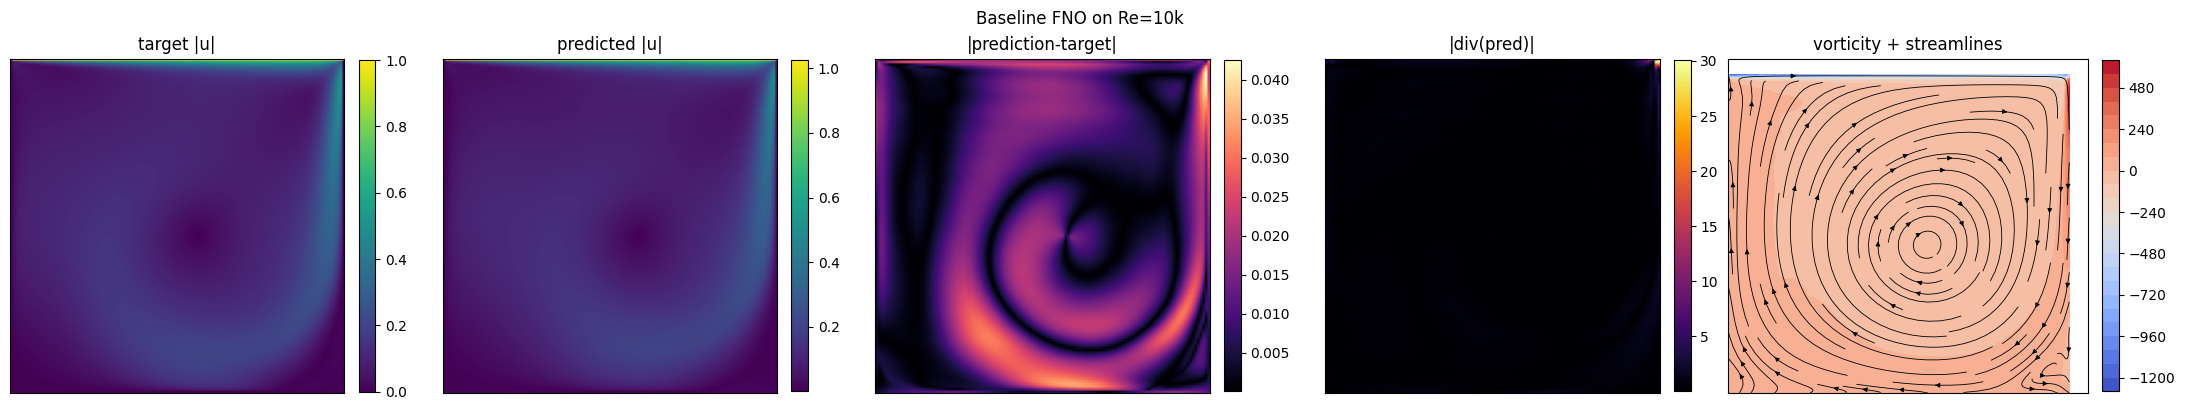

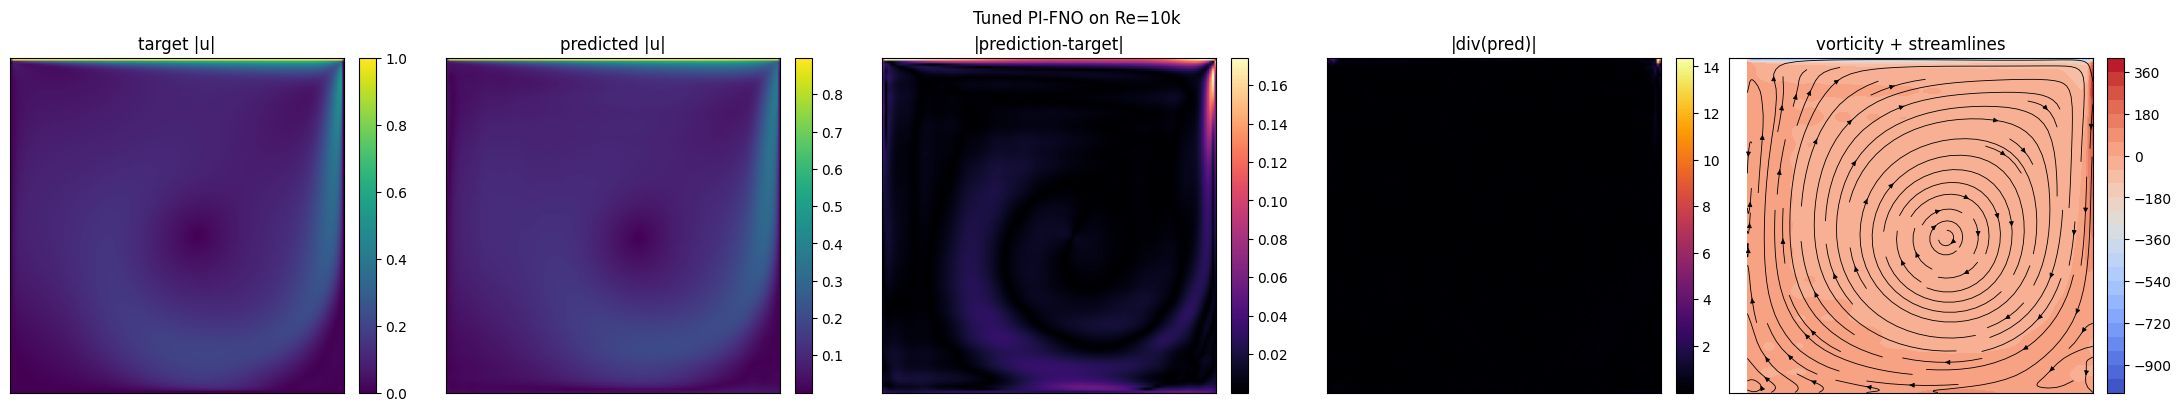

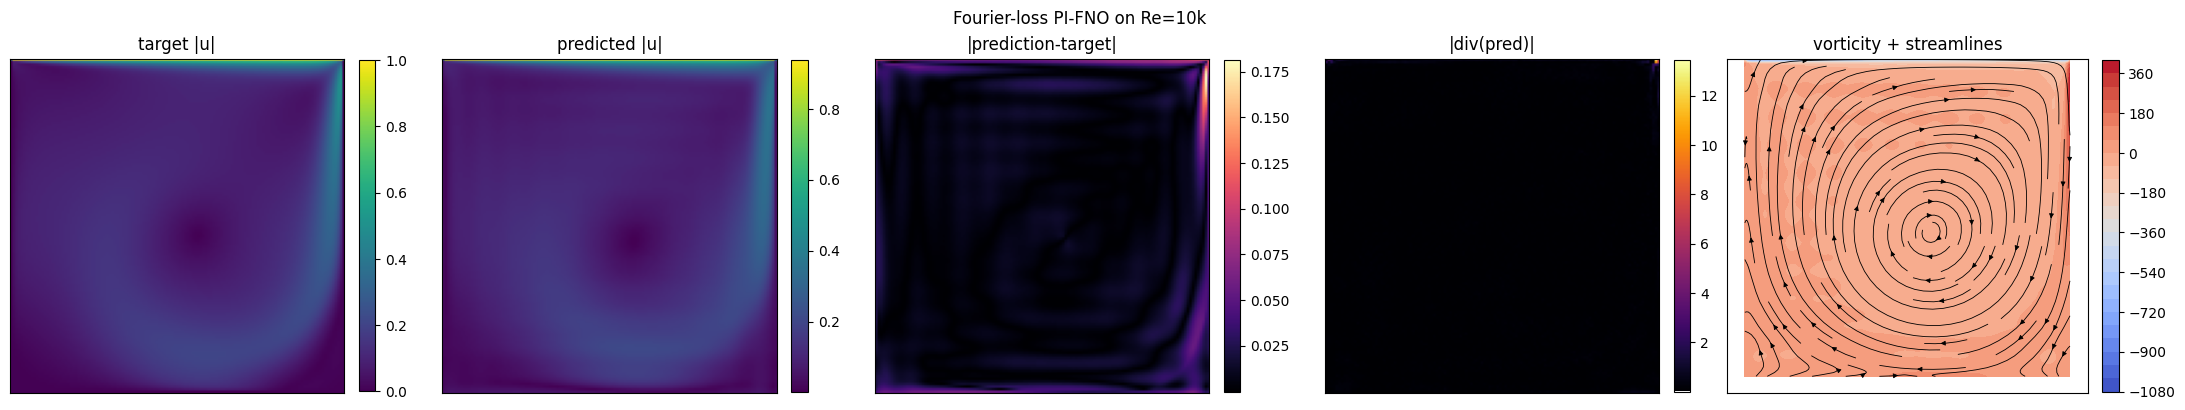

In [16]:
def velocity_magnitude(field: np.ndarray, u_index: int = 1, v_index: int = 2) -> np.ndarray:
    return np.sqrt(field[..., u_index, :] ** 2 + field[..., v_index, :] ** 2)


def vorticity_2d(field: np.ndarray, domain_length: float, u_index: int = 1, v_index: int = 2) -> np.ndarray:
    u = field[..., u_index, 0]
    v = field[..., v_index, 0]
    height, width = u.shape
    dx = domain_length / (width - 1)
    dy = domain_length / (height - 1)
    return np.gradient(v, dx, axis=1) - np.gradient(u, dy, axis=0)


@torch.no_grad()
def predict_dataset_sample(
    model: nn.Module,
    dataset: CavityWindowDataset,
    index: int,
    config: ProjectConfig,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    x, y = dataset[index]
    prediction = autoregressive_rollout(
        model,
        x.unsqueeze(0).to(device),
        config.pred_steps,
        config.output_steps,
    ).cpu()[0]
    return x.numpy(), y.numpy(), prediction.numpy()


def plot_prediction_sample(
    model: nn.Module,
    dataset: CavityWindowDataset,
    index: int,
    config: ProjectConfig,
    device: torch.device,
    title: str = 'FNO prediction',
):
    x, y, prediction = predict_dataset_sample(model, dataset, index, config, device)
    target_mag = velocity_magnitude(y, config.u_index, config.v_index)[..., 0]
    pred_mag = velocity_magnitude(prediction, config.u_index, config.v_index)[..., 0]
    error_mag = np.abs(pred_mag - target_mag)

    height, width = target_mag.shape
    dx = config.domain_length / (width - 1)
    dy = config.domain_length / (height - 1)
    pred_tensor = torch.from_numpy(prediction).unsqueeze(0)
    div_map = finite_difference_divergence(pred_tensor, dx, dy, config.u_index, config.v_index)[0, :, :, 0].numpy()
    vort = vorticity_2d(prediction, config.domain_length, config.u_index, config.v_index)

    x_coords = np.linspace(0.0, config.domain_length, width)
    y_coords = np.linspace(0.0, config.domain_length, height)
    u = prediction[..., config.u_index, 0]
    v = prediction[..., config.v_index, 0]

    fig, axes = plt.subplots(1, 5, figsize=(22, 4), constrained_layout=True)
    image_panels = [
        (target_mag, 'target |u|', 'viridis'),
        (pred_mag, 'predicted |u|', 'viridis'),
        (error_mag, '|prediction-target|', 'magma'),
        (np.abs(div_map), '|div(pred)|', 'inferno'),
    ]
    for axis, (image, subtitle, cmap) in zip(axes[:4], image_panels):
        im = axis.imshow(image, origin='lower', cmap=cmap, extent=[0, config.domain_length, 0, config.domain_length])
        axis.set_title(subtitle)
        axis.set_xticks([])
        axis.set_yticks([])
        fig.colorbar(im, ax=axis, fraction=0.046, pad=0.04)

    contour = axes[4].contourf(x_coords, y_coords, vort, levels=24, cmap='coolwarm')
    axes[4].streamplot(x_coords, y_coords, u, v, color='k', density=1.0, linewidth=0.6, arrowsize=0.7)
    axes[4].set_title('vorticity + streamlines')
    axes[4].set_xticks([])
    axes[4].set_yticks([])
    fig.colorbar(contour, ax=axes[4], fraction=0.046, pad=0.04)

    fig.suptitle(title)
    return fig

# Save qualitative samples for the report.
baseline_fig = plot_prediction_sample(baseline_model, val_dataset, index=0, config=baseline_cfg, device=device, title='Baseline FNO on Re=10k')
baseline_fig.savefig(cfg.figure_dir / 'baseline_re10k_sample0.png', dpi=200)

pifno_fig = plot_prediction_sample(pifno_model, val_dataset, index=0, config=pifno_cfg, device=device, title='Tuned PI-FNO on Re=10k')
pifno_fig.savefig(cfg.figure_dir / 'pifno_tuned_re10k_sample0.png', dpi=200)

fourier_fig = plot_prediction_sample(fourier_loss_model, val_dataset, index=0, config=fourier_loss_cfg, device=device, title='Fourier-loss PI-FNO on Re=10k')
fourier_fig.savefig(cfg.figure_dir / 'fourier_loss_re10k_sample0.png', dpi=200)


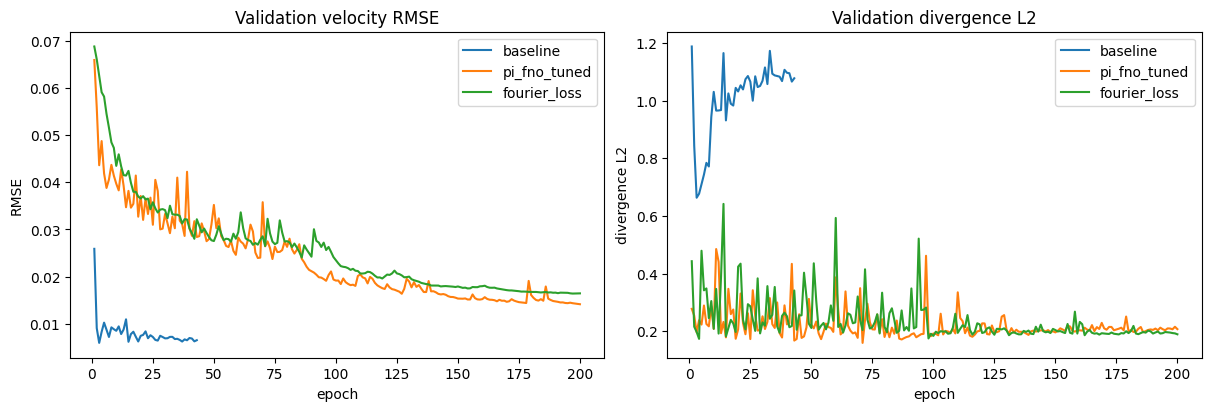

In [17]:
def plot_training_history(histories: dict[str, list[dict]]):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    for label, history in histories.items():
        epochs = [row['epoch'] for row in history]
        axes[0].plot(epochs, [row['val_rmse_velocity'] for row in history], label=label)
        axes[1].plot(epochs, [row['val_divergence_l2'] for row in history], label=label)
    axes[0].set_title('Validation velocity RMSE')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('RMSE')
    axes[0].legend()
    axes[1].set_title('Validation divergence L2')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('divergence L2')
    axes[1].legend()
    return fig

fig = plot_training_history({
    'baseline': baseline_history,
    'pi_fno_tuned': pifno_history,
    'fourier_loss': fourier_loss_history,
})
fig.savefig(cfg.figure_dir / 'training_history.png', dpi=200)


## 10. Result Interpretation

The final tables and figures should be interpreted through the accuracy-physics tradeoff.

A data-only FNO is expected to minimize velocity RMSE because its objective directly optimizes field reconstruction. A physics-informed FNO may have higher RMSE, but it should reduce divergence error and produce a more physically consistent velocity field. The Fourier-loss ablation tests whether spectral supervision changes this tradeoff by emphasizing low-frequency flow structures.

The main conclusions should compare:

1. Velocity RMSE for predictive accuracy.
2. Divergence L2 for incompressibility.
3. Boundary RMSE for lid and wall behavior.
4. Held-out Reynolds-number performance for generalization.
5. Seed/window-offset standard deviation for training stability.
6. Vorticity and streamline plots for qualitative flow structure.

